# Problem Statement

## Context

In the realm of modern finance, businesses encounter the perpetual challenge of managing debt obligations effectively to maintain a favorable credit standing and foster sustainable growth. Investors keenly scrutinize companies capable of navigating financial complexities while ensuring stability and profitability. A pivotal instrument in this evaluation process is the balance sheet, which provides a comprehensive overview of a company's assets, liabilities, and shareholder equity, offering insights into its financial health and operational efficiency. In this context, leveraging available financial data, particularly from preceding fiscal periods, becomes imperative for informed decision-making and strategic planning.

## Objective

A renowned credit rating organization wants to develop a Financial Health Assessment Tool. With the help of the tool, it endeavors to empower businesses and investors with a robust mechanism for evaluating the financial well-being and creditworthiness of companies. By harnessing machine learning techniques, the organization aims to analyze historical financial statements and extract pertinent insights to facilitate informed decision-making via the tool. Specifically, the organization foresees facilitating the following with the help of the tool:

1. Debt Management Analysis: Identify patterns and trends in debt management practices to assess the ability of businesses to fulfill financial obligations promptly and efficiently, and identify potential cases of default.

2. Credit Risk Evaluation: Evaluate credit risk exposure by analyzing liquidity ratios, debt-to-equity ratios, and other key financial indicators to ascertain the likelihood of default and inform investment decisions.

As a part of the data science team in the organization, you have been provided with the financial metrics of different companies. The task is to analyze the data provided and develop a predictive model leveraging machine learning techniques to identify whether a given company will default on its debt repayments in the next two quarters. The predictive model will help the organization anticipate potential challenges with the financial performance of the companies and enable proactive risk mitigation strategies.

## Data Dictionary

The data consists of financial metrics from the balance sheets of different companies. The detailed data dictionary is available in the data dictionary file (*FRA_DataDictionary.xlsx*).

# **Please read the instructions carefully before starting the project.**

This is a commented Python Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.
* Add the results/observations (wherever mentioned) derived from the analysis in the presentation and submit the same.

# Importing necessary libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, GridSearchCV    # Train test Split and Grid Search
from sklearn.ensemble import RandomForestClassifier

import statsmodels.api as SM
from sklearn import metrics

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container { width:90% !important; }<\style>'))

<>:32: SyntaxWarning: invalid escape sequence '\s'
<>:32: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nilan\AppData\Local\Temp\ipykernel_4836\228102314.py:32: SyntaxWarning: invalid escape sequence '\s'
  display(HTML('<style>.container { width:90% !important; }<\style>'))


# Loading the Data

In [2]:
# uncomment and run the following lines for Google Colab
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
df = pd.read_excel('CompData.xlsx')  ##  Fill the blank to read the data
df.head()

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,...,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
0,16974,Hind.Cables,8.820000e+09,0.000000e+00,0.462045,0.000352,0.001417,0.322558,0.194472,0.022074,...,0.310901,0.034913,0,0.028801,0.620927,0.026930,0.565744,1,0.015338,0
1,21214,Tata Tele. Mah.,9.380000e+09,4.230000e+09,0.460116,0.000716,0.000000,0.315520,0.161633,0.021902,...,0.314572,0.041653,0,0.006191,0.622513,0.026297,0.560741,1,0.029445,1
2,14852,ABG Shipyard,3.800000e+09,8.150000e+08,0.449893,0.000496,0.000000,0.299851,0.172554,0.022186,...,0.314777,0.033560,0,0.001095,0.623749,0.027276,0.566744,1,0.041718,0
3,2439,GTL,6.440000e+09,0.000000e+00,0.462731,0.000592,0.009313,0.319834,0.174738,0.027638,...,0.316974,0.016527,0,0.003749,0.622963,0.026988,0.565950,1,0.026956,0
4,23505,Bharati Defence,3.680000e+09,0.000000e+00,0.463117,0.000782,0.400243,0.325104,0.176546,0.022072,...,0.317729,0.034497,0,0.006595,0.624419,0.027498,0.567177,1,0.019900,0


# Data Overview

In [4]:
df.head(5) ##  Complete the code to view top 5 rows of the data

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,...,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
0,16974,Hind.Cables,8.820000e+09,0.000000e+00,0.462045,0.000352,0.001417,0.322558,0.194472,0.022074,...,0.310901,0.034913,0,0.028801,0.620927,0.026930,0.565744,1,0.015338,0
1,21214,Tata Tele. Mah.,9.380000e+09,4.230000e+09,0.460116,0.000716,0.000000,0.315520,0.161633,0.021902,...,0.314572,0.041653,0,0.006191,0.622513,0.026297,0.560741,1,0.029445,1
2,14852,ABG Shipyard,3.800000e+09,8.150000e+08,0.449893,0.000496,0.000000,0.299851,0.172554,0.022186,...,0.314777,0.033560,0,0.001095,0.623749,0.027276,0.566744,1,0.041718,0
3,2439,GTL,6.440000e+09,0.000000e+00,0.462731,0.000592,0.009313,0.319834,0.174738,0.027638,...,0.316974,0.016527,0,0.003749,0.622963,0.026988,0.565950,1,0.026956,0
4,23505,Bharati Defence,3.680000e+09,0.000000e+00,0.463117,0.000782,0.400243,0.325104,0.176546,0.022072,...,0.317729,0.034497,0,0.006595,0.624419,0.027498,0.567177,1,0.019900,0


In [5]:
df.tail(5) ##  Complete the code to view last 5 rows of the data

,Co_Code,Co_Name,_Operating_Expense_Rate,_Research_and_development_expense_rate,_Cash_flow_rate,_Interest_bearing_debt_interest_rate,_Tax_rate_A,_Cash_Flow_Per_Share,_Per_Share_Net_profit_before_tax_Yuan_,_Realized_Sales_Gross_Profit_Growth_Rate,...,_Cash_Flow_to_Equity,_Current_Liability_to_Current_Assets,_Liability_Assets_Flag,_Total_assets_to_GNP_price,_No_credit_Interval,_Degree_of_Financial_Leverage_DFL,_Interest_Coverage_Ratio_Interest_expense_to_EBIT,_Net_Income_Flag,_Equity_to_Liability,Default
2053,2743,Kothari Ferment.,3.021580e-04,6.490000e+09,0.477066,0.000000,0.183014,0.322063,0.192739,0.022127,...,0.320387,0.004430,0,0.000420,0.624567,0.026791,0.565158,1,0.171662,0
2054,21216,Firstobj.Tech.,1.371450e-04,0.000000e+00,0.465211,0.000658,0.000000,0.319764,0.169391,0.022072,...,0.312324,0.032284,0,0.000882,0.624008,0.024201,0.573670,1,0.053740,0
2055,142,Diamines & Chem.,2.114990e-04,8.370000e+09,0.480248,0.000502,0.000000,0.327828,0.155005,0.021861,...,0.313122,0.040998,0,0.009579,0.623718,0.026702,0.564697,1,0.054984,0
2056,18014,IL&FS Engg.,3.750000e+09,0.000000e+00,0.474670,0.000578,0.306205,0.322027,0.173834,0.022167,...,0.315632,0.020275,0,0.004958,0.623443,0.026943,0.565792,1,0.057553,0
2057,43229,Channel Nine,2.981110e-04,0.000000e+00,0.467203,0.000826,0.000000,0.330021,0.180236,0.022418,...,0.316734,0.031368,0,0.000186,0.623588,0.026871,0.565512,1,0.020266,0


In [6]:
df.shape ##  Complete the code to view dimensions of the data

(2058, 58)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 58 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Co_Code                                            2058 non-null   int64  
 1   Co_Name                                            2058 non-null   object 
 2   _Operating_Expense_Rate                            2058 non-null   float64
 3   _Research_and_development_expense_rate             2058 non-null   float64
 4   _Cash_flow_rate                                    2058 non-null   float64
 5   _Interest_bearing_debt_interest_rate               2058 non-null   float64
 6   _Tax_rate_A                                        2058 non-null   float64
 7   _Cash_Flow_Per_Share                               1891 non-null   float64
 8   _Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 9   _Realize

In [8]:
# Remove '_' (startswith) from column headers where present
for col in df.columns:
    if col.startswith('_'):
        df.rename(columns={col: col[1:]}, inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2058 entries, 0 to 2057
Data columns (total 58 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Co_Code                                           2058 non-null   int64  
 1   Co_Name                                           2058 non-null   object 
 2   Operating_Expense_Rate                            2058 non-null   float64
 3   Research_and_development_expense_rate             2058 non-null   float64
 4   Cash_flow_rate                                    2058 non-null   float64
 5   Interest_bearing_debt_interest_rate               2058 non-null   float64
 6   Tax_rate_A                                        2058 non-null   float64
 7   Cash_Flow_Per_Share                               1891 non-null   float64
 8   Per_Share_Net_profit_before_tax_Yuan_             2058 non-null   float64
 9   Realized_Sales_Gros

In [10]:
# checking for duplicate values
df.duplicated().sum() ##  Complete the code to check duplicate entries in the data

0

In [11]:
#checking for no. of unique values
df.nunique() ##  Complete the code to check unique entries in the data

Co_Code                                             2058
Co_Name                                             2058
Operating_Expense_Rate                              1495
Research_and_development_expense_rate                629
Cash_flow_rate                                      1888
Interest_bearing_debt_interest_rate                  813
Tax_rate_A                                           985
Cash_Flow_Per_Share                                  900
Per_Share_Net_profit_before_tax_Yuan_                876
Realized_Sales_Gross_Profit_Growth_Rate             1939
Operating_Profit_Growth_Rate                        2015
Continuous_Net_Profit_Growth_Rate                   2014
Total_Asset_Growth_Rate                              922
Net_Value_Growth_Rate                               1757
Total_Asset_Return_Growth_Rate_Ratio                1428
Cash_Reinvestment_perc                              1690
Current_Ratio                                       1972
Quick_Ratio                    

In [12]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Co_Code,2058.0,1.757211e+04,2.189289e+04,4.000000,3.674000e+03,6.240000e+03,2.428075e+04,7.249300e+04
Operating_Expense_Rate,2058.0,2.052389e+09,3.252624e+09,0.000100,1.578727e-04,3.330330e-04,4.110000e+09,9.980000e+09
Research_and_development_expense_rate,2058.0,1.208634e+09,2.144568e+09,0.000000,0.000000e+00,1.994130e-04,1.550000e+09,9.980000e+09
Cash_flow_rate,2058.0,4.652426e-01,2.266269e-02,0.000000,4.600991e-01,4.634450e-01,4.680691e-01,1.000000e+00
Interest_bearing_debt_interest_rate,2058.0,1.113022e+07,9.042595e+07,0.000000,2.760280e-04,4.540450e-04,6.630660e-04,9.900000e+08
Tax_rate_A,2058.0,1.147770e-01,1.524457e-01,0.000000,0.000000e+00,3.709890e-02,2.161909e-01,9.996963e-01
Cash_Flow_Per_Share,1891.0,3.199856e-01,1.529979e-02,0.169449,3.149890e-01,3.206479e-01,3.259178e-01,4.622268e-01
Per_Share_Net_profit_before_tax_Yuan_,2058.0,1.769673e-01,3.015730e-02,0.000000,1.666039e-01,1.756421e-01,1.858854e-01,7.923477e-01
Realized_Sales_Gross_Profit_Growth_Rate,2058.0,2.276117e-02,2.170104e-02,0.004282,2.205831e-02,2.210001e-02,2.215200e-02,1.000000e+00
Operating_Profit_Growth_Rate,2058.0,8.481083e-01,4.589093e-03,0.736430,8.479740e-01,8.480386e-01,8.481147e-01,1.000000e+00


* We can see that `Co_Code` and `Co_Name` are not relevant for this exercise
* So we will drop these variables

In [13]:
df.drop(['Co_Code', 'Co_Name'], axis = 1, inplace = True)

#Exploratory Data Analysis

## Univariate Analysis

In [14]:
df["Default"].nunique()   ## Complete the code to check unique values in the mentioned column

2

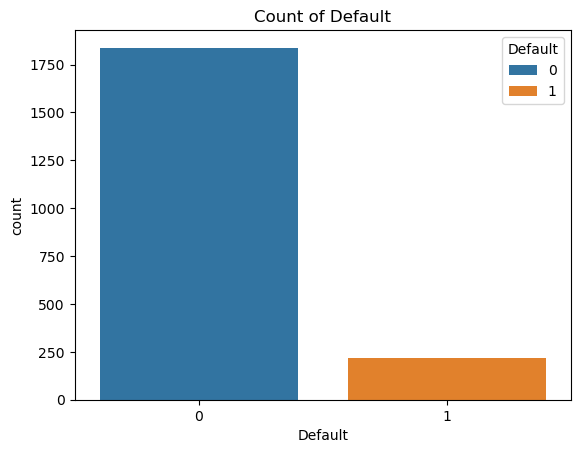

In [15]:
#Plotting a countplot for the target variable
sns.countplot(x = "Default", data = df, hue = 'Default')   ## Complete the code to get a countplot of the mentionedd column.
plt.title('Count of Default')
plt.show()

In [16]:
#Percentage of defaulters
(df.Default.sum()/len(df)) * 100

10.689990281827017

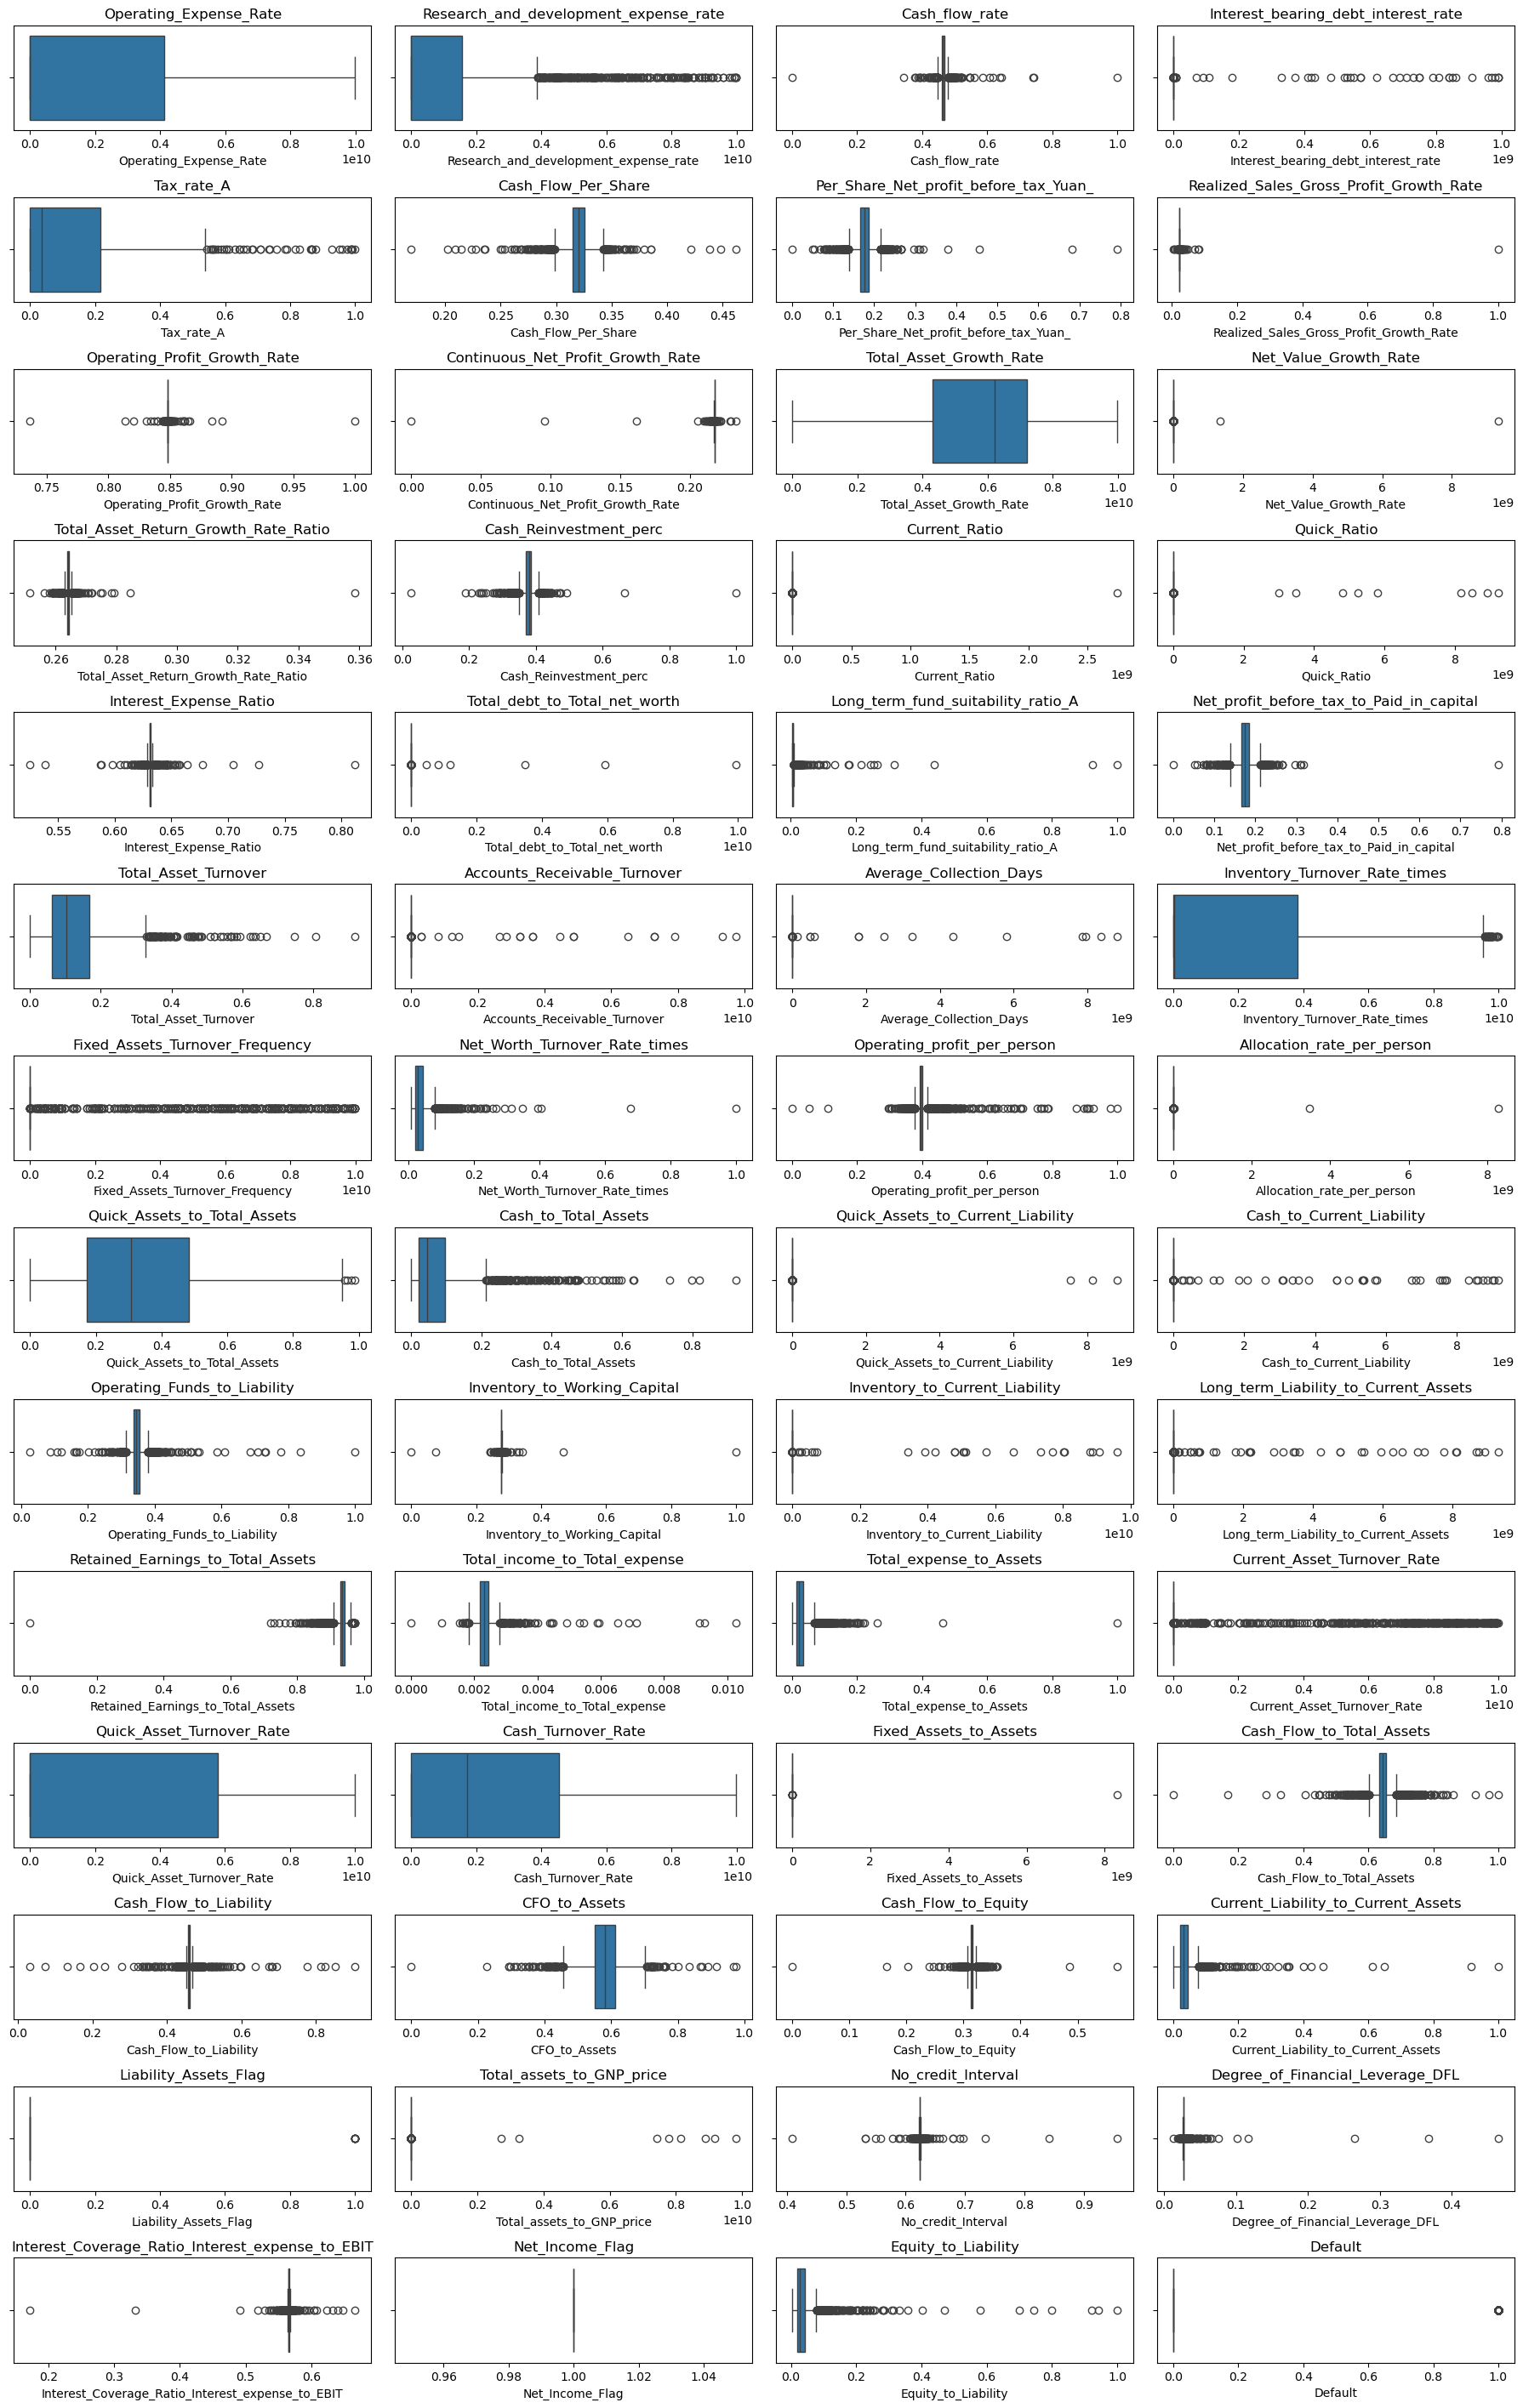

In [17]:
#Get boxplots for all the numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(15, 4, i + 1)
    sns.boxplot(data=df, x=variable)  ## Complete the code to get boxplots for all numerical columns
    plt.tight_layout()
    plt.title(variable)
plt.show()

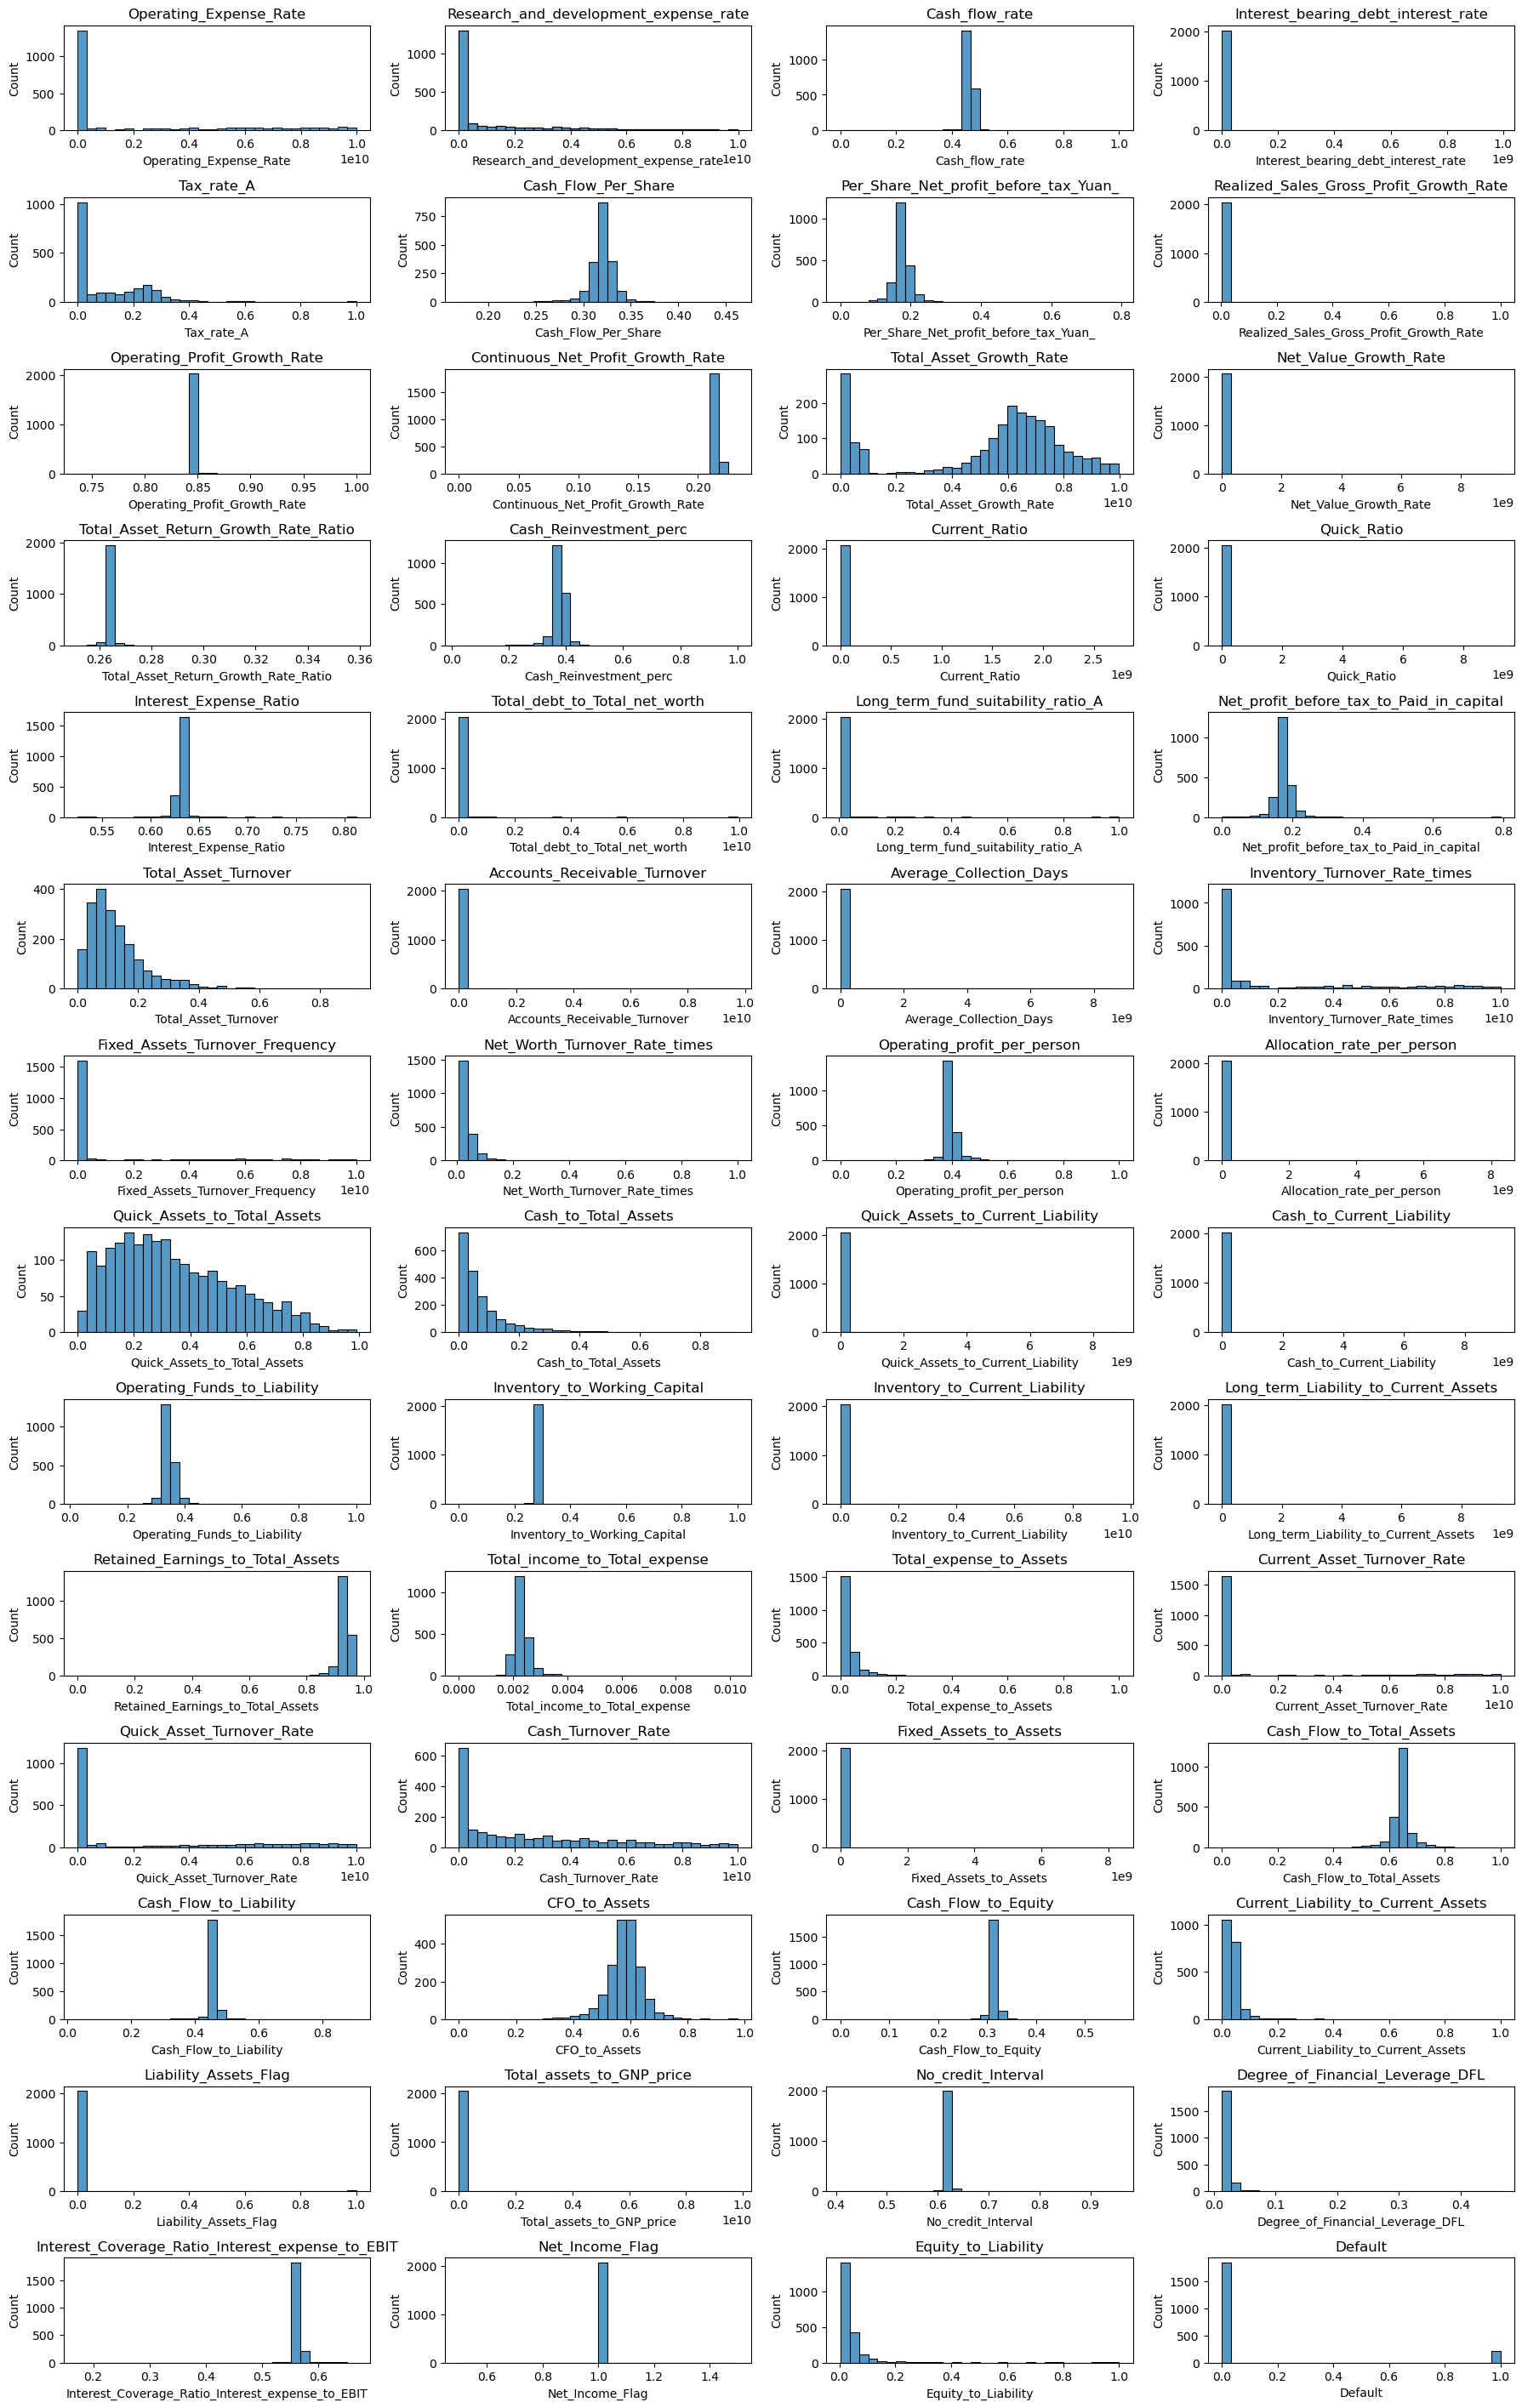

In [18]:
#Get distplot for all the numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(15, 4, i + 1)
    sns.histplot(data=df, x=variable, bins=30)  ## Complete the code to get histplot for all numerical columns in the data
    plt.tight_layout()
    plt.title(variable)
plt.show()

## Bivariate Analysis

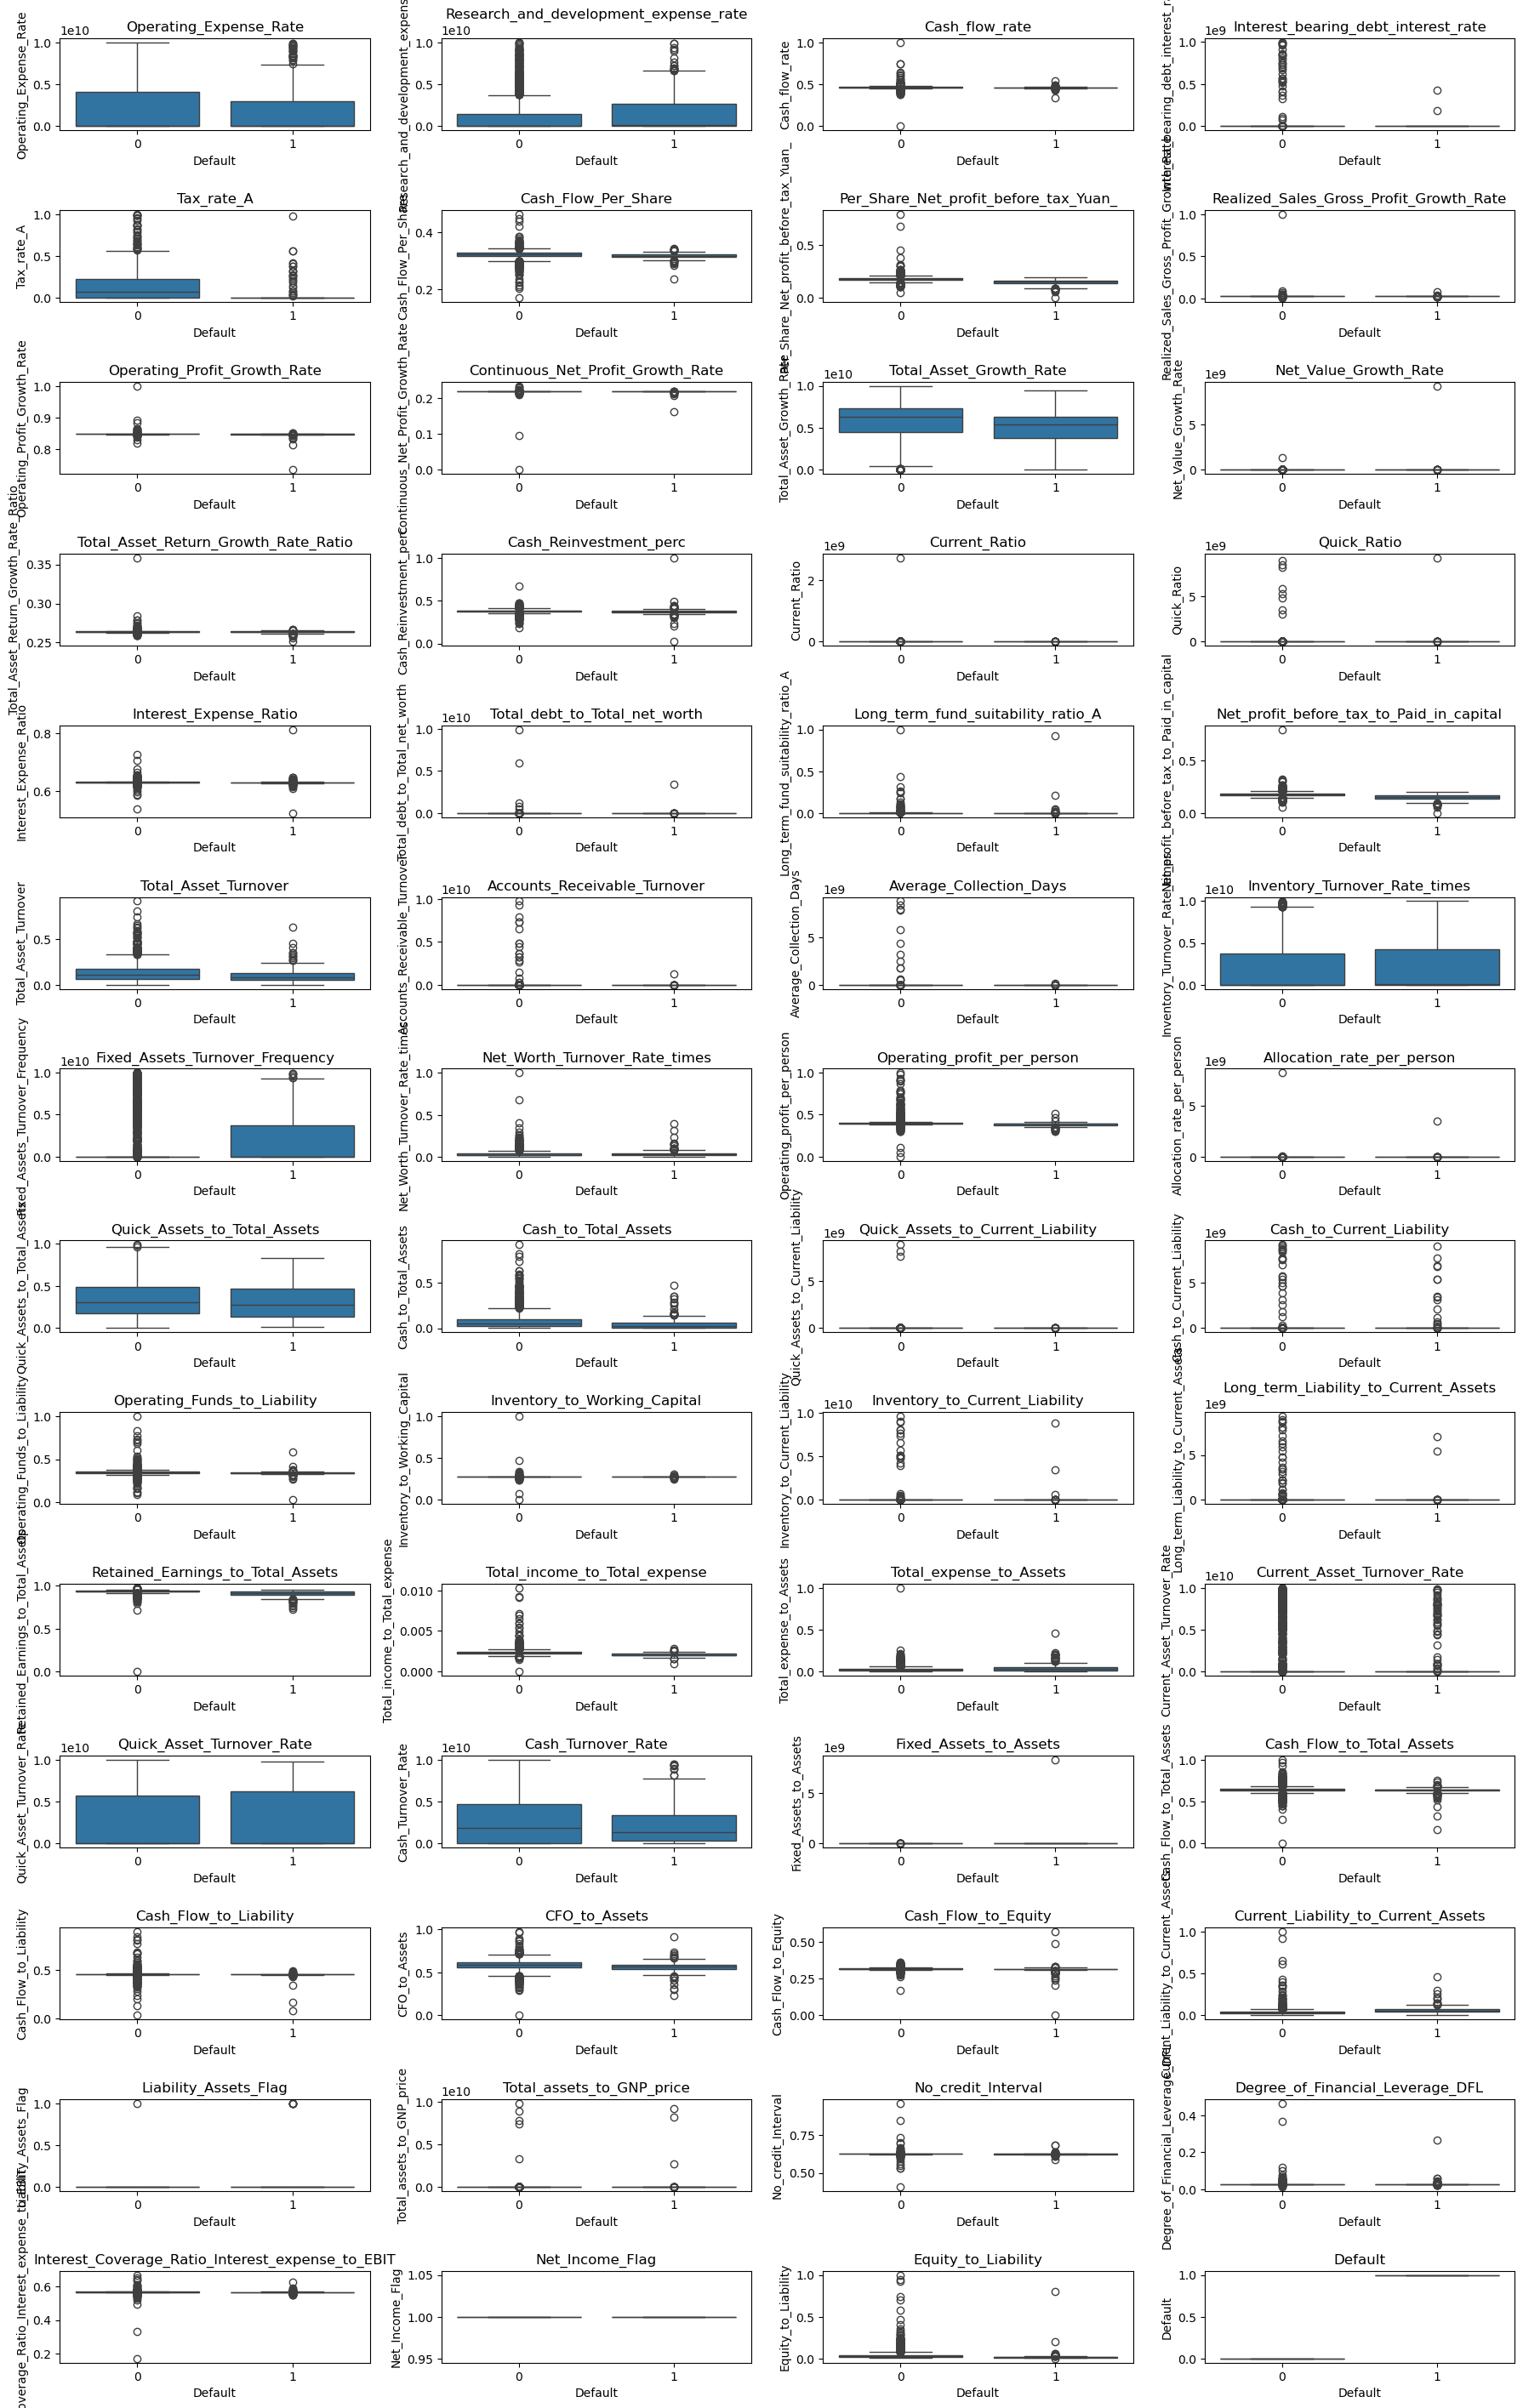

In [19]:
#Get boxplots for all the numerical columns
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(18, 30))

for i, variable in enumerate(numeric_columns):
    plt.subplot(15, 4, i + 1)
    sns.boxplot(x="Default", y=variable, data=df)  ## Complete the code to get boxplot of all variables with Default column in the data
    plt.tight_layout()
    plt.title(variable)
plt.show()

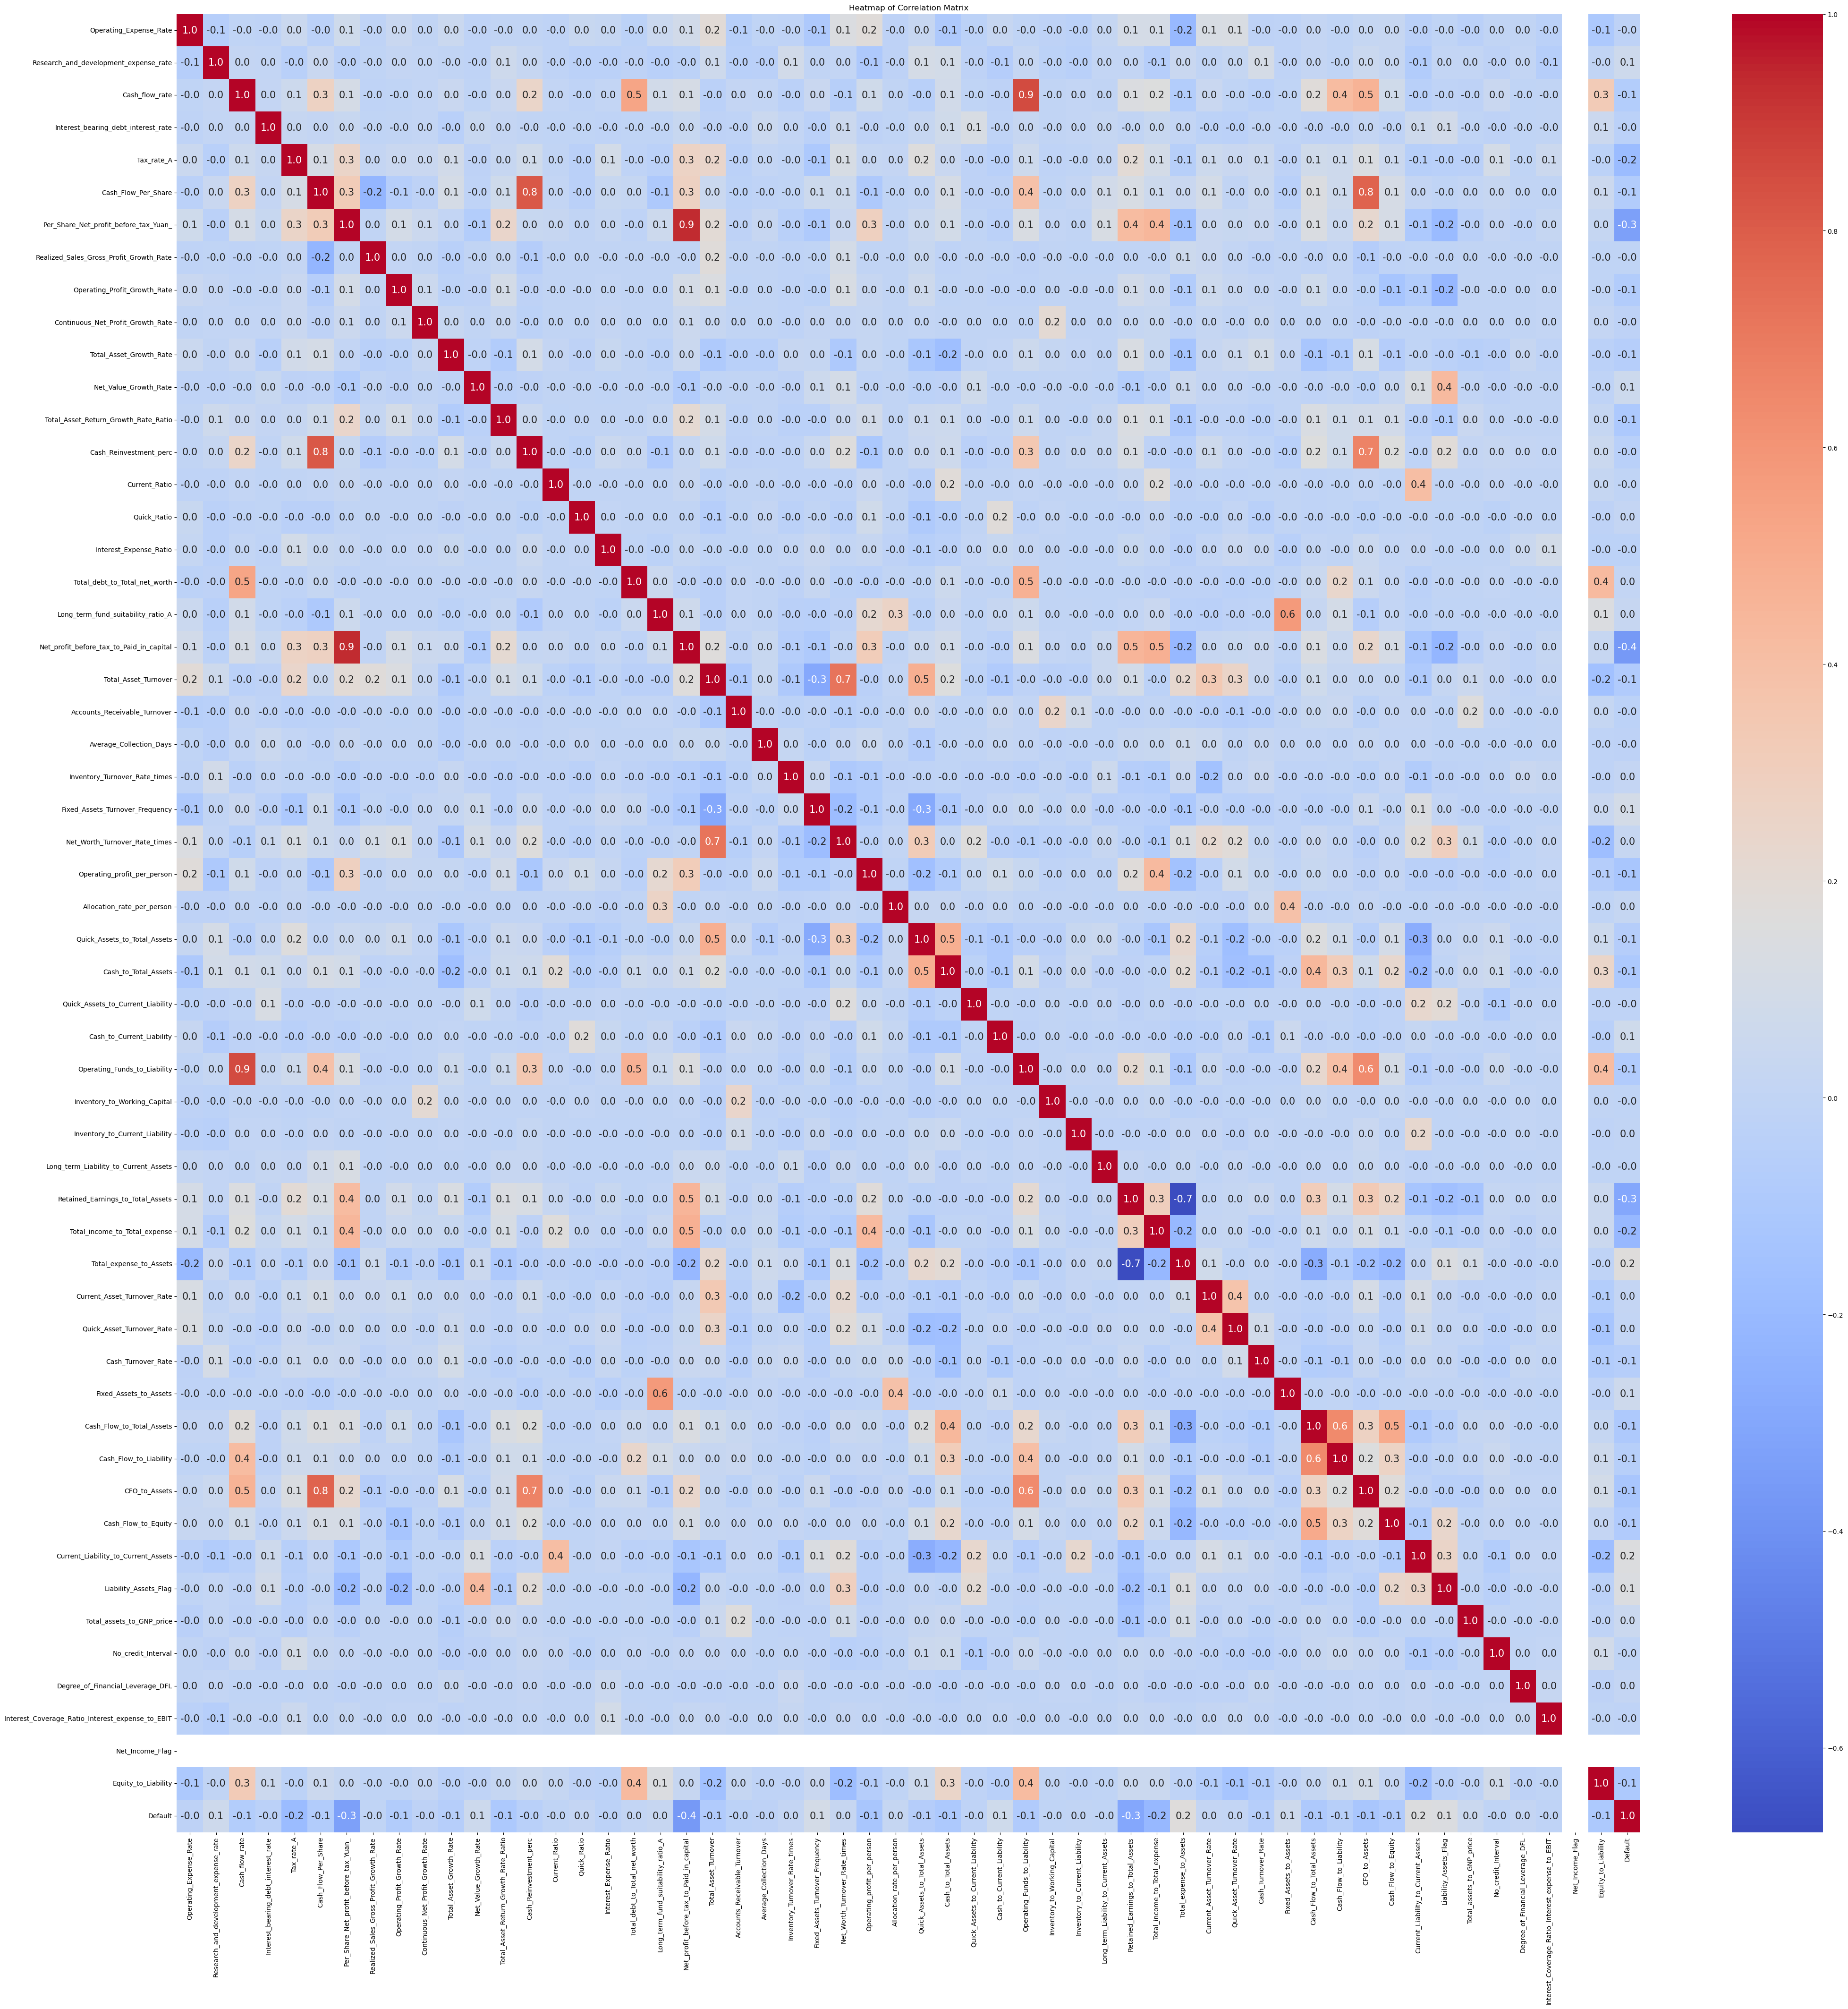

In [20]:
# Calculate the correlation matrix
corr_matrix = df.corr(numeric_only=True)  ## Complete the code to get the correlation matrix for the data

# Create a heatmap of the correlation matrix
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".1f", annot_kws={"size": 15})
plt.title('Heatmap of Correlation Matrix')
plt.show()

# Data Preprocessing

## Dropping columns with few unique values

In [21]:
df.nunique()

Operating_Expense_Rate                              1495
Research_and_development_expense_rate                629
Cash_flow_rate                                      1888
Interest_bearing_debt_interest_rate                  813
Tax_rate_A                                           985
Cash_Flow_Per_Share                                  900
Per_Share_Net_profit_before_tax_Yuan_                876
Realized_Sales_Gross_Profit_Growth_Rate             1939
Operating_Profit_Growth_Rate                        2015
Continuous_Net_Profit_Growth_Rate                   2014
Total_Asset_Growth_Rate                              922
Net_Value_Growth_Rate                               1757
Total_Asset_Return_Growth_Rate_Ratio                1428
Cash_Reinvestment_perc                              1690
Current_Ratio                                       1972
Quick_Ratio                                         1970
Interest_Expense_Ratio                              1716
Total_debt_to_Total_net_worth  

We can drop the columns `Net_Income_Flag` and `Liability_Assets_Flag` as they have very few unique values.

In [22]:
df.drop(['Net_Income_Flag', 'Liability_Assets_Flag'], axis = 1, inplace = True)  ## Complete the code to drop the mentioned columns from the dataset
df.nunique()

Operating_Expense_Rate                              1495
Research_and_development_expense_rate                629
Cash_flow_rate                                      1888
Interest_bearing_debt_interest_rate                  813
Tax_rate_A                                           985
Cash_Flow_Per_Share                                  900
Per_Share_Net_profit_before_tax_Yuan_                876
Realized_Sales_Gross_Profit_Growth_Rate             1939
Operating_Profit_Growth_Rate                        2015
Continuous_Net_Profit_Growth_Rate                   2014
Total_Asset_Growth_Rate                              922
Net_Value_Growth_Rate                               1757
Total_Asset_Return_Growth_Rate_Ratio                1428
Cash_Reinvestment_perc                              1690
Current_Ratio                                       1972
Quick_Ratio                                         1970
Interest_Expense_Ratio                              1716
Total_debt_to_Total_net_worth  

## Outliers Check

In [23]:
outliers_count = {}

# Iterate over each column in the DataFrame
for column in df.columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR  ## Fill the blank with correct value for getting lower_bound
    upper_bound = Q3 + 1.5 * IQR  ## Fill the blank with correct value for getting upper_bound

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outliers_count[column] = len(outliers)

print("Number of outliers in each column:")
pd.DataFrame([{'Column': column, 'No. of outliers': outliers} for column, outliers in outliers_count.items()])

Number of outliers in each column:


,Column,No. of outliers
0,Operating_Expense_Rate,0
1,Research_and_development_expense_rate,264
2,Cash_flow_rate,206
3,Interest_bearing_debt_interest_rate,94
4,Tax_rate_A,42
5,Cash_Flow_Per_Share,146
6,Per_Share_Net_profit_before_tax_Yuan_,186
7,Realized_Sales_Gross_Profit_Growth_Rate,283
8,Operating_Profit_Growth_Rate,317
9,Continuous_Net_Profit_Growth_Rate,340


## Data Preparation for Modeling

In [24]:
# Seperating target variable from the rest of the data
df_X = df.drop(['Default'], axis = 1)
df_y = df['Default']

In [25]:
#Splitting the data for training and testing
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.25, random_state=42, stratify = df_y)  ## Complete the code to split the data into train and test in the ratio 75:25

## Missing Values Detection and Treatment

In [26]:
# Check missing values
X_train.isnull().sum()  ## Complete the code to get the number of null or NaN values in each column

Operating_Expense_Rate                                0
Research_and_development_expense_rate                 0
Cash_flow_rate                                        0
Interest_bearing_debt_interest_rate                   0
Tax_rate_A                                            0
Cash_Flow_Per_Share                                 126
Per_Share_Net_profit_before_tax_Yuan_                 0
Realized_Sales_Gross_Profit_Growth_Rate               0
Operating_Profit_Growth_Rate                          0
Continuous_Net_Profit_Growth_Rate                     0
Total_Asset_Growth_Rate                               0
Net_Value_Growth_Rate                                 0
Total_Asset_Return_Growth_Rate_Ratio                  0
Cash_Reinvestment_perc                                0
Current_Ratio                                         0
Quick_Ratio                                           0
Interest_Expense_Ratio                                0
Total_debt_to_Total_net_worth                   

In [27]:
# Check missing values
X_test.isnull().sum()

Operating_Expense_Rate                               0
Research_and_development_expense_rate                0
Cash_flow_rate                                       0
Interest_bearing_debt_interest_rate                  0
Tax_rate_A                                           0
Cash_Flow_Per_Share                                 41
Per_Share_Net_profit_before_tax_Yuan_                0
Realized_Sales_Gross_Profit_Growth_Rate              0
Operating_Profit_Growth_Rate                         0
Continuous_Net_Profit_Growth_Rate                    0
Total_Asset_Growth_Rate                              0
Net_Value_Growth_Rate                                0
Total_Asset_Return_Growth_Rate_Ratio                 0
Cash_Reinvestment_perc                               0
Current_Ratio                                        0
Quick_Ratio                                          0
Interest_Expense_Ratio                               0
Total_debt_to_Total_net_worth                        3
Long_term_

In [28]:
#Replace the missing values in the data using KNN Imputer
KNNimputerModel = KNNImputer(n_neighbors=5)  ## Complete the code to select 5 neighbors for KNN Imputer

X_train = pd.DataFrame(KNNimputerModel.fit_transform(X_train), columns = X_train.columns)
X_test = pd.DataFrame(KNNimputerModel.transform(X_test), columns = X_test.columns)  ## Complete the code to replace missing values in X_test

In [29]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


## Scaling the Data

In [30]:
#Scaling of features is done to bring all the features to the same scale.
sc = StandardScaler()

X_train_scaled = pd.DataFrame(sc.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(sc.transform(X_test), columns=X_test.columns)  ## Complete the code to scale X_test to the same scale as X_train

In [31]:
X_train_scaled.head()

,Operating_Expense_Rate,Research_and_development_expense_rate,Cash_flow_rate,Interest_bearing_debt_interest_rate,Tax_rate_A,Cash_Flow_Per_Share,Per_Share_Net_profit_before_tax_Yuan_,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,Continuous_Net_Profit_Growth_Rate,...,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Total_assets_to_GNP_price,No_credit_Interval,Degree_of_Financial_Leverage_DFL,Interest_Coverage_Ratio_Interest_expense_to_EBIT,Equity_to_Liability
0,-0.633296,-0.396806,-0.132455,-0.128462,-0.754347,0.088170,-0.902611,-0.156311,-0.129315,0.021636,...,-0.152255,-0.026487,0.101957,-0.141788,0.469507,-0.054112,-0.034152,-0.092390,-0.057822,-0.469266
1,-0.633296,-0.561672,-0.934352,-0.128462,-0.754347,-1.224514,-1.111709,-10.373320,-0.055710,0.038318,...,-0.163912,-0.045322,-2.637987,-0.085051,1.075174,-0.054112,-0.004818,-0.083738,-0.018937,-0.200363
2,-0.633296,0.361946,-0.290335,-0.128462,0.061964,-0.409659,0.227000,-0.087271,-0.023725,0.037770,...,-0.636642,-0.170355,-0.477991,-0.363851,0.116437,-0.054112,0.004516,-0.060604,0.056889,-0.266282
3,-0.633296,-0.561672,-0.179548,-0.128462,-0.754347,-0.077773,-0.482011,-0.188306,-0.069048,0.038921,...,-0.042653,-0.006164,-0.123538,-0.041367,1.150645,-0.054112,4.471330,-0.122720,-0.290236,-0.531511
4,-0.633296,-0.561672,-0.123892,-0.128462,-0.754347,-0.168422,-0.768019,-0.247137,-0.027705,0.035840,...,0.294471,0.073490,-0.101885,0.197825,1.009522,-0.054112,0.028995,-0.089020,-0.041776,-0.338544


In [32]:
X_test_scaled.head()

,Operating_Expense_Rate,Research_and_development_expense_rate,Cash_flow_rate,Interest_bearing_debt_interest_rate,Tax_rate_A,Cash_Flow_Per_Share,Per_Share_Net_profit_before_tax_Yuan_,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,Continuous_Net_Profit_Growth_Rate,...,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Total_assets_to_GNP_price,No_credit_Interval,Degree_of_Financial_Leverage_DFL,Interest_Coverage_Ratio_Interest_expense_to_EBIT,Equity_to_Liability
0,-0.633296,1.539557,0.118477,-0.128462,-0.754347,0.053496,-0.748792,0.180520,-0.011102,0.036105,...,0.193130,0.043684,1.380659,0.152775,0.182134,21.284878,0.002471,-0.084419,-0.021737,-0.393241
1,2.016795,0.135659,0.441752,-0.128462,-0.754347,0.164950,-0.373857,-0.082321,-0.023865,0.030979,...,-0.163593,-0.074189,0.280352,-0.068218,-0.136638,-0.054112,0.030465,-0.122151,-0.283547,0.266472
2,-0.633296,0.177222,-0.141279,-0.128462,0.085538,0.112938,0.082794,-0.128307,-0.036322,0.039894,...,-0.726657,-0.181901,-0.023374,-0.443208,0.596316,-0.054112,-0.285331,-0.065638,0.043047,-0.307438
3,-0.633296,2.144527,-0.666470,-0.128462,-0.754347,-0.986745,-2.765267,-0.228174,-0.323804,-0.017845,...,-2.249473,-0.432505,-2.301248,-2.021203,-0.185659,-0.054112,0.005825,-0.083999,-0.020004,-0.443594
4,0.763746,0.301910,-0.050325,-0.128462,0.719997,0.578569,0.376013,-0.081416,-0.024988,0.038193,...,0.054646,0.014723,0.445480,0.044805,-0.251142,-0.054112,0.038812,-0.080425,-0.005872,-0.368514


#Model Building

## Model Evaluation Criterion

*Metric of Choice*
-


In [33]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification(model, predictors, target, threshold = 0.5):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    y_pred = model.predict(predictors)

    if len(list(set(y_pred))) != 2:
        y_prob_pred = model.predict(predictors)

        y_pred=[]
        for i in range(0,len(y_prob_pred)):
            if np.array(y_prob_pred)[i] > threshold:
                a=1
            else:
                a=0
            y_pred.append(a)
    else:
        pass

    acc = accuracy_score(target, y_pred)  # to compute Accuracy
    recall = recall_score(target, y_pred)  # to compute Recall
    precision = precision_score(target, y_pred)  # to compute Precision
    f1 = f1_score(target, y_pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [34]:
def model_confusion_matrix(model, predictors, target, threshold = 0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    if len(list(set(y_pred))) != 2:
        y_prob_pred = model.predict(predictors)

        y_pred=[]
        for i in range(0,len(y_prob_pred)):
            if np.array(y_prob_pred)[i] > threshold:
                a=1
            else:
                a=0
            y_pred.append(a)
    else:
        pass

    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Logistic Regression

In [35]:
# Adding constant to data for Logistic Regression
X_train_with_intercept = SM.add_constant(X_train_scaled)
X_test_with_intercept = SM.add_constant(X_test_scaled)

In [36]:
X_train_with_intercept.head()

,const,Operating_Expense_Rate,Research_and_development_expense_rate,Cash_flow_rate,Interest_bearing_debt_interest_rate,Tax_rate_A,Cash_Flow_Per_Share,Per_Share_Net_profit_before_tax_Yuan_,Realized_Sales_Gross_Profit_Growth_Rate,Operating_Profit_Growth_Rate,...,Cash_Flow_to_Total_Assets,Cash_Flow_to_Liability,CFO_to_Assets,Cash_Flow_to_Equity,Current_Liability_to_Current_Assets,Total_assets_to_GNP_price,No_credit_Interval,Degree_of_Financial_Leverage_DFL,Interest_Coverage_Ratio_Interest_expense_to_EBIT,Equity_to_Liability
0,1.0,-0.633296,-0.396806,-0.132455,-0.128462,-0.754347,0.088170,-0.902611,-0.156311,-0.129315,...,-0.152255,-0.026487,0.101957,-0.141788,0.469507,-0.054112,-0.034152,-0.092390,-0.057822,-0.469266
1,1.0,-0.633296,-0.561672,-0.934352,-0.128462,-0.754347,-1.224514,-1.111709,-10.373320,-0.055710,...,-0.163912,-0.045322,-2.637987,-0.085051,1.075174,-0.054112,-0.004818,-0.083738,-0.018937,-0.200363
2,1.0,-0.633296,0.361946,-0.290335,-0.128462,0.061964,-0.409659,0.227000,-0.087271,-0.023725,...,-0.636642,-0.170355,-0.477991,-0.363851,0.116437,-0.054112,0.004516,-0.060604,0.056889,-0.266282
3,1.0,-0.633296,-0.561672,-0.179548,-0.128462,-0.754347,-0.077773,-0.482011,-0.188306,-0.069048,...,-0.042653,-0.006164,-0.123538,-0.041367,1.150645,-0.054112,4.471330,-0.122720,-0.290236,-0.531511
4,1.0,-0.633296,-0.561672,-0.123892,-0.128462,-0.754347,-0.168422,-0.768019,-0.247137,-0.027705,...,0.294471,0.073490,-0.101885,0.197825,1.009522,-0.054112,0.028995,-0.089020,-0.041776,-0.338544


In [37]:
y_train.reset_index(inplace = True, drop = True)

In [38]:
LogisticReg = SM.Logit(y_train, X_train_with_intercept).fit()   ## Complete the code to define Logistic Regression Model
print(LogisticReg.summary())

         Current function value: 0.193946
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                 1543
Model:                          Logit   Df Residuals:                     1489
Method:                           MLE   Df Model:                           53
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                  0.4297
Time:                        11:35:47   Log-Likelihood:                -299.26
converged:                      False   LL-Null:                       -524.71
Covariance Type:            nonrobust   LLR p-value:                 1.764e-64
                                                       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
const                                               -7.4685   2410.7

### Logistic Regression Model - Training Performance

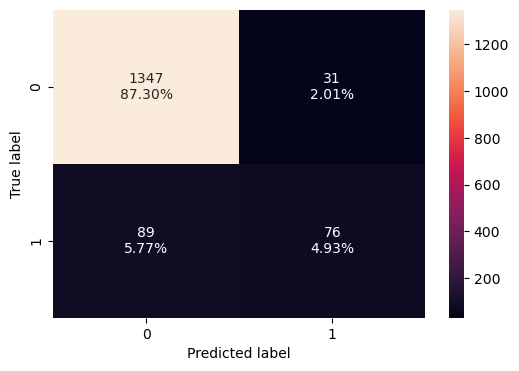

In [39]:
model_confusion_matrix(LogisticReg, X_train_with_intercept, y_train)

In [40]:
logistic_regression_perf_train = model_performance_classification(LogisticReg, X_train_with_intercept, y_train)
logistic_regression_perf_train

,Accuracy,Recall,Precision,F1
0,0.922229,0.460606,0.71028,0.558824


### Logistic Regression Model - Test Performance

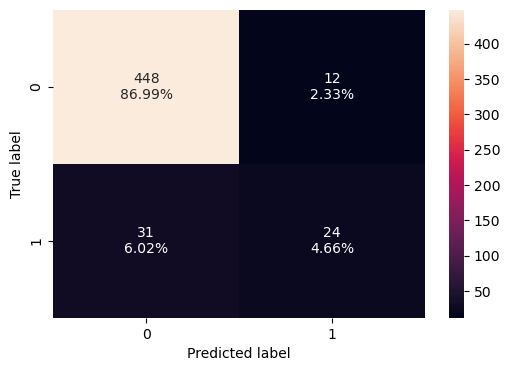

In [41]:
model_confusion_matrix(LogisticReg, X_test_with_intercept, y_test)  ## Complete the code to create confusion matrix for test data

In [42]:
logistic_regression_perf_test = model_performance_classification(LogisticReg, X_test_with_intercept, y_test)  ## Complete the code to check performance on test data
logistic_regression_perf_test

,Accuracy,Recall,Precision,F1
0,0.916505,0.436364,0.666667,0.527473


## Random Forest

In [43]:
rf_classifier = RandomForestClassifier(random_state=42)  ## Complete the code to define random forest with random state = 42
rf_model = rf_classifier.fit(X_train, y_train) ## Complete the code to fit random forest on the train data

### Random Forest Model - Training Performance

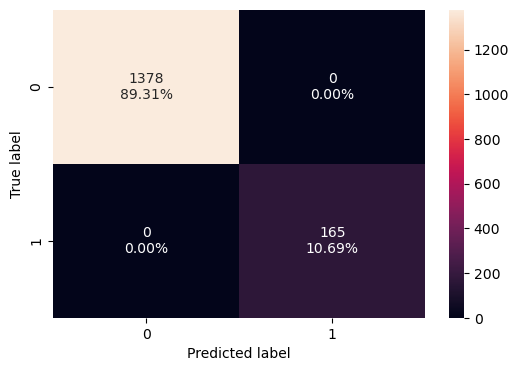

In [44]:
model_confusion_matrix(rf_model, X_train, y_train)

In [45]:
random_forest_perf_train = model_performance_classification(rf_model, X_train, y_train)
random_forest_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### Random Forest Model - Test Performance

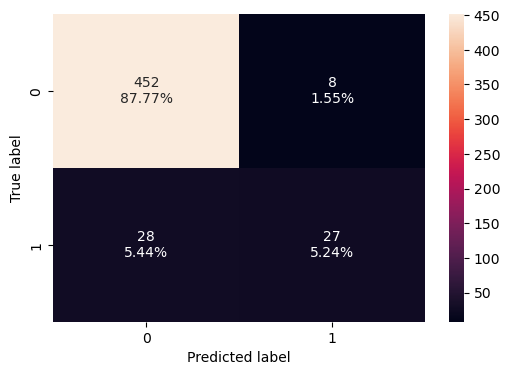

In [46]:
model_confusion_matrix(rf_model, X_test, y_test)  ## Complete the code to create confusion matrix for test data

In [47]:
random_forest_perf_test = model_performance_classification(rf_model, X_test, y_test)  ## Complete the code to check performance on test data
random_forest_perf_test

,Accuracy,Recall,Precision,F1
0,0.930097,0.490909,0.771429,0.6


# Model Performance Improvement

## Model Performance Improvement - Logistic Regression

In [48]:
def calculate_vif(idf):
    """
    Calculate Variance Inflation Factor (VIF) for each variable in a DataFrame.

    Parameters:
    df (DataFrame): Input DataFrame containing numerical variables.

    Returns:
    vif_df (DataFrame): DataFrame containing variable names and their corresponding VIF values.
    """
    variables = idf.values
    vif_df = pd.DataFrame()
    vif_df["Variable"] = idf.columns
    vif_df["VIF"] = [variance_inflation_factor(variables, i) for i in range(idf.shape[1])]
    return vif_df

In [49]:
# Call the function to calculate VIF
vif_result = calculate_vif(X_train_scaled)  ## Complete the code to calculate VIF for the scaled X_train data

print("Variance Inflation Factors:")
vif_result

Variance Inflation Factors:


,Variable,VIF
0,Operating_Expense_Rate,1.259611
1,Research_and_development_expense_rate,1.099306
2,Cash_flow_rate,12.259184
3,Interest_bearing_debt_interest_rate,1.032597
4,Tax_rate_A,1.248346
5,Cash_Flow_Per_Share,4.564430
6,Per_Share_Net_profit_before_tax_Yuan_,8.756612
7,Realized_Sales_Gross_Profit_Growth_Rate,1.058517
8,Operating_Profit_Growth_Rate,1.152581
9,Continuous_Net_Profit_Growth_Rate,1.467948


In [50]:
high_vif_columns = []
for i, row in vif_result.iterrows():
    if row['VIF'] >= 5:
        high_vif_columns.append(row['Variable'])
high_vif_columns

['Cash_flow_rate',
 'Per_Share_Net_profit_before_tax_Yuan_',
 'Cash_Reinvestment_perc',
 'Net_profit_before_tax_to_Paid_in_capital',
 'Total_Asset_Turnover',
 'Operating_Funds_to_Liability',
 'CFO_to_Assets']

In [51]:
# Dropping columns with VIF > 5
X_train_scaled.drop(columns = high_vif_columns, axis=1, inplace=True)
X_test_scaled.drop(columns = high_vif_columns, axis=1, inplace=True)

In [52]:
X_train_scaled.shape

(1543, 46)

In [53]:
X_test_scaled.shape

(515, 46)

In [54]:
X_train_new_with_intercept = SM.add_constant(X_train_scaled)
X_test_new_with_intercept = SM.add_constant(X_test_scaled)

In [55]:
# Retraining Logistic Regression Model with new data
LogisticReg_improved = SM.Logit(y_train, X_train_new_with_intercept).fit(method='bfgs', maxiter=100)  ## Complete the code to fir Logistic Regression Model on new train data with intercept
print(LogisticReg_improved.summary())

         Current function value: 0.201099
         Iterations: 100
         Function evaluations: 101
         Gradient evaluations: 101
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:                 1543
Model:                          Logit   Df Residuals:                     1496
Method:                           MLE   Df Model:                           46
Date:                Thu, 17 Oct 2024   Pseudo R-squ.:                  0.4086
Time:                        11:36:44   Log-Likelihood:                -310.30
converged:                      False   LL-Null:                       -524.71
Covariance Type:            nonrobust   LLR p-value:                 1.462e-63
                                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------

In [56]:
# Finding Optimal Threshold value
logit_y_pred = LogisticReg_improved.predict(X_train_new_with_intercept)
fpr, tpr, thresholds = roc_curve(y_train, logit_y_pred)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_logit = round(thresholds[optimal_idx], 3)
optimal_threshold_logit

0.084

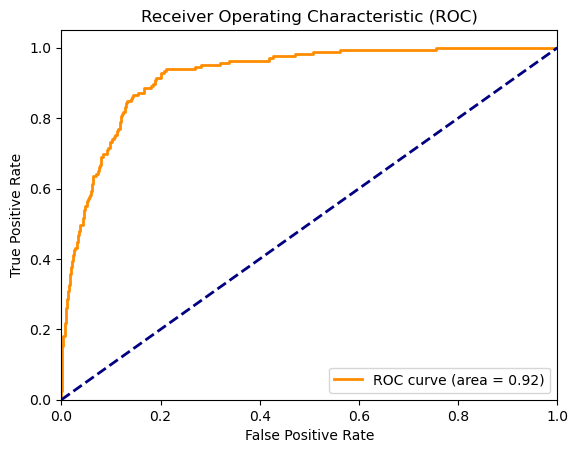

In [57]:
roc_auc = roc_auc_score(y_train, logit_y_pred)  ## Complete the code to get roc_auc score
# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### Logistic Regression Performance - Training Set

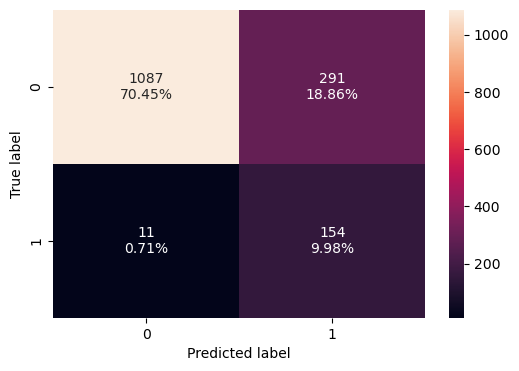

In [58]:
model_confusion_matrix(LogisticReg_improved, X_train_new_with_intercept, y_train, optimal_threshold_logit)

In [59]:
logistic_regression_tuned_perf_train = model_performance_classification(
    LogisticReg_improved, X_train_new_with_intercept, y_train, optimal_threshold_logit
)
logistic_regression_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,0.804277,0.933333,0.346067,0.504918


### Logistic Regression Performance - Test Set

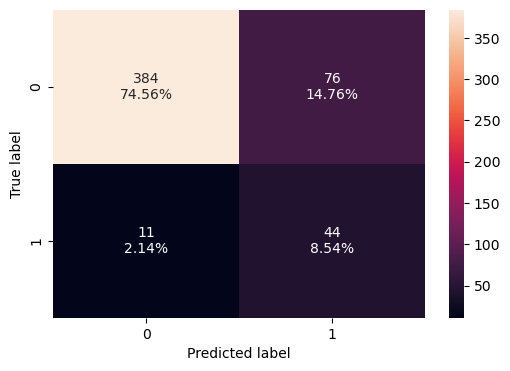

In [60]:
model_confusion_matrix(LogisticReg_improved, X_test_new_with_intercept, y_test, optimal_threshold_logit)  ## Complete the code to create confusion matrix for test data

In [61]:
logistic_regression_tuned_perf_test = model_performance_classification(LogisticReg_improved, X_test_new_with_intercept, y_test, optimal_threshold_logit)  ## Complete the code to check performance on test data
logistic_regression_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.831068,0.8,0.366667,0.502857


## Model Performance Improvement - Random Forest

In [62]:
param_grid = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [5, 7, 9],    # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],    # Minimum number of samples required to split a node
    'min_samples_leaf': [5, 6, 7],  # Minimum number of samples required at each leaf node
}

rf_classifier = RandomForestClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'max_depth': 5, 'min_samples_leaf': 7, 'min_samples_split': 2, 'n_estimators': 200}


In [63]:
# Access the best estimator directly if needed
best_rf_classifier = grid_search.best_estimator_

In [64]:
params_used = best_rf_classifier.get_params()

# Print the parameters
print("Parameters used in the Random Forest Classifier:")
for param_name, param_value in params_used.items():
    print(f"{param_name}: {param_value}")

Parameters used in the Random Forest Classifier:
bootstrap: True
ccp_alpha: 0.0
class_weight: balanced
criterion: gini
max_depth: 5
max_features: sqrt
max_leaf_nodes: None
max_samples: None
min_impurity_decrease: 0.0
min_samples_leaf: 7
min_samples_split: 2
min_weight_fraction_leaf: 0.0
monotonic_cst: None
n_estimators: 200
n_jobs: None
oob_score: False
random_state: 42
verbose: 0
warm_start: False


### Random Forest Performance - Training Set

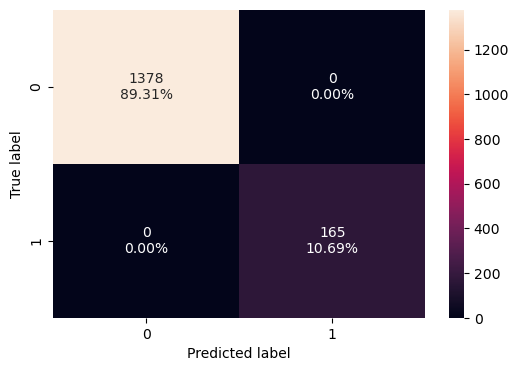

In [70]:
rf_classifier.fit(X_train_new_with_intercept, y_train)
model_confusion_matrix(rf_classifier, X_train_new_with_intercept, y_train)  ## Complete the code to create confusion matrix for training data

In [71]:
random_forest_tuned_perf_train = model_performance_classification(rf_classifier, X_train_new_with_intercept, y_train)  ## Complete the code to check performance on training data
random_forest_tuned_perf_train

,Accuracy,Recall,Precision,F1
0,1.0,1.0,1.0,1.0


### Random Forest Performance - Test Set

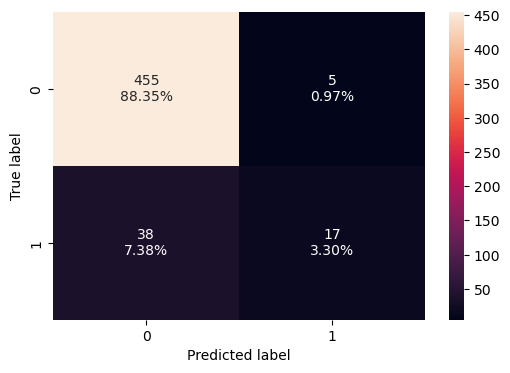

In [72]:
model_confusion_matrix(rf_classifier, X_test_new_with_intercept, y_test)  ## Complete the code to create confusion matrix for test data

In [73]:
random_forest_tuned_perf_test = model_performance_classification(rf_classifier, X_test_new_with_intercept, y_test)  ## Complete the code to check performance on test data
random_forest_tuned_perf_test

,Accuracy,Recall,Precision,F1
0,0.916505,0.309091,0.772727,0.441558


# Model Comparison and Final Model Selection

In [74]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        logistic_regression_perf_train.T,
        logistic_regression_tuned_perf_train.T,
        random_forest_perf_train.T,
        random_forest_tuned_perf_train.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Tuned Logistic Regression",
    "Random Forest",
    "Tuned Random Forest",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression,Tuned Logistic Regression,Random Forest,Tuned Random Forest
Accuracy,0.922229,0.804277,1.0,1.0
Recall,0.460606,0.933333,1.0,1.0
Precision,0.710280,0.346067,1.0,1.0
F1,0.558824,0.504918,1.0,1.0


In [75]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        logistic_regression_perf_test.T,
        logistic_regression_tuned_perf_test.T,
        random_forest_perf_test.T,
        random_forest_tuned_perf_test.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression",
    "Tuned Logistic Regression",
    "Random Forest",
    "Tuned Random Forest",
]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Logistic Regression,Tuned Logistic Regression,Random Forest,Tuned Random Forest
Accuracy,0.916505,0.831068,0.930097,0.916505
Recall,0.436364,0.800000,0.490909,0.309091
Precision,0.666667,0.366667,0.771429,0.772727
F1,0.527473,0.502857,0.600000,0.441558


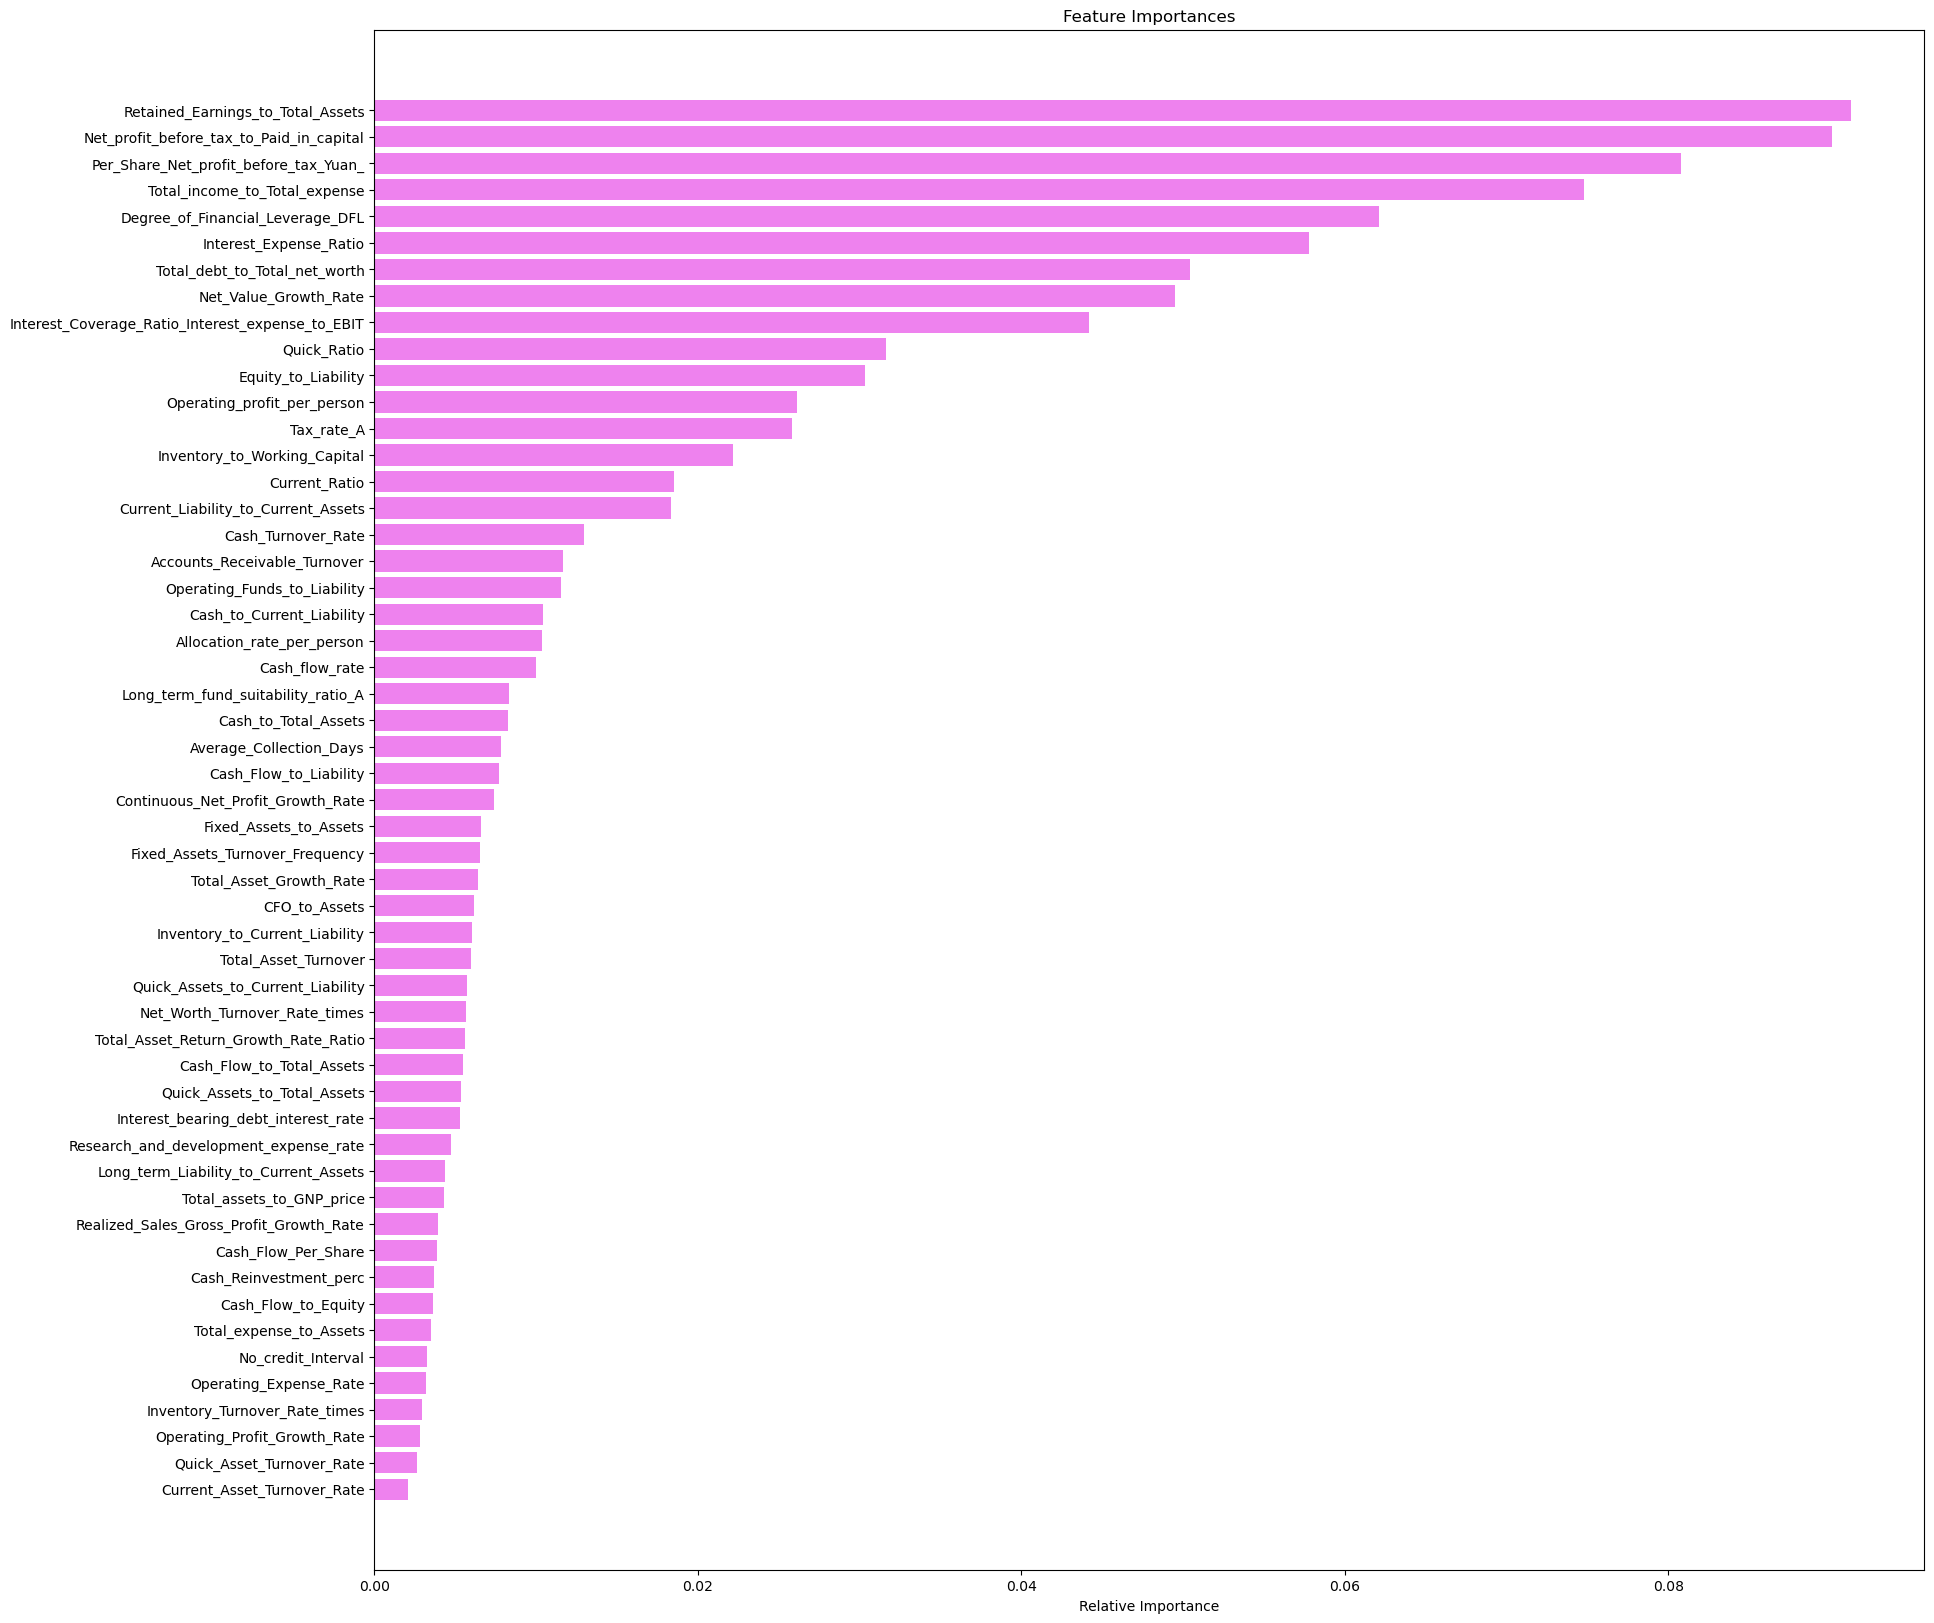

In [76]:
feature_names = X_train.columns
importances = best_rf_classifier.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(20, 20))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

# Conclusions and Recommendations

*

___